#LAB 9 - MLP

###Author: Mikołaj Jędruch

First we create the neural network. The same we made in lab.

In [ ]:
import torch

N = 100
focus1 = torch.tensor([-2.0, 0.0])             # First focus,                        sized (2)
points = torch.rand((N, 2)) * 10 - 5           # Uniformly distributed in [-5, 5]    sized (N, 2)

############### when we computed distances to focal points ##############################
dist1 = torch.norm(points - focus1, dim=1)     # the focus 1 gets expanded to (1, 2) then broadcasted to (N, 2)
                                               # to match the points tensor

                                               # effectively what happens is that
                                               # the focus point gets substracted from every other point

                                               # also: note how natural this notation feels here

############### when we computed pairwise point-to-point distances #####################
# Compute all pairwise distances in parallel
print(points.unsqueeze(1).size())                   # sized: (N, 1, 2)
print(points.unsqueeze(0).size())                   # sized: (1, N, 2)

diffs = points.unsqueeze(1) - points.unsqueeze(0)   # sized: (N, N, 2) because of broadcasting
distances = torch.norm(diffs, dim=-1)               # sized: (N, N)

print(distances.size())

torch.Size([100, 1, 2])
torch.Size([1, 100, 2])
torch.Size([100, 100])


In [ ]:
import torch
import torchvision
from matplotlib import pyplot

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=None)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.99MB/s]


In [ ]:
transform = torchvision.transforms.Compose(
    [ torchvision.transforms.ToTensor(), #Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
      torchvision.transforms.Normalize((0.1307), (0.3081))])

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=2048,
                                          shuffle=True)   #we do shuffle it to give more randomizations to training epochs

testset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=1,
                                         shuffle=False)

In [ ]:
for i, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        if i<5:
            print(i, "-th batch labels :", batch_labels)

0 -th batch labels : tensor([8, 0, 5,  ..., 3, 4, 2])
1 -th batch labels : tensor([1, 5, 5,  ..., 2, 5, 6])
2 -th batch labels : tensor([5, 5, 9,  ..., 9, 4, 9])
3 -th batch labels : tensor([7, 5, 4,  ..., 9, 0, 7])
4 -th batch labels : tensor([8, 4, 3,  ..., 8, 4, 1])


In [ ]:
for i, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        if i==0:
            print(i, "-th batch inputs :", batch_inputs)

0 -th batch inputs : tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
     

In [ ]:
class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = torch.nn.Sequential(   #Sequential is a structure which allows stacking layers one on another in such a way,
                                          #that output from a preceding layer serves as input to the next layer
            torch.nn.Flatten(),   #change the last three orders in data (with dimensions 1, 28 and 28 respectively) into one order of dimensions (1*28*28)
            torch.nn.Linear(1*28*28, 1024),  #which is used as INPUT to the first Linear layer
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 2048),   #IMPORTANT! Please observe, that the OUTPUT dimension of a preceding layer is always equal to the INPUT dimension of the next layer.
            torch.nn.ReLU(),
            torch.nn.Linear(2048, 256),
            torch.nn.ReLU(),            #ReLU (or a Sigmoid if you want) is a nonlinear function which is used in-between layers
            torch.nn.Linear(256, 10),
        )
        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):
        x = self.mlp(x)
        x = self.dropout(x)
        return x


In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

net = MLP().to(device)
optimizer = torch.optim.Adam(net.parameters(), 0.001)   #initial and fixed learning rate of 0.001.

net.train()    #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing traning
for epoch in range(8):  #  an epoch is a training run through the whole data set

    for batch, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        batch_inputs = batch_inputs.to(device)  #explicitly moving the data to the target device
        batch_labels = batch_labels.to(device)

        #batch_inputs.squeeze(1)     #alternatively if not for a Flatten layer, squeeze() could be used to remove the second order of the tensor, the Channel, which is one-dimensional (this index can be equal to 0 only)

        optimizer.zero_grad()

        batch_outputs = net(batch_inputs)   #this line calls the forward(self, x) method of the MLP object. Please note, that the last layer of the MLP is linear
                                            #and MLP doesn't apply
                                            #the nonlinear activation after the last layer
        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels, reduction = "mean") #instead, nonlinear softmax is applied internally in THIS loss function
        print("epoch:", epoch, "batch:", batch, "current batch loss:", loss.item())
        loss.backward()       #this computes gradients as we have seen in previous workshops
        optimizer.step()     #but this line in fact updates our neural network.
                                ####You can experiment - comment this line and check, that the loss DOE

Working on cpu
epoch: 0 batch: 0 current batch loss: 2.3053483963012695
epoch: 0 batch: 1 current batch loss: 2.0877158641815186
epoch: 0 batch: 2 current batch loss: 1.627276062965393
epoch: 0 batch: 3 current batch loss: 1.1412078142166138
epoch: 0 batch: 4 current batch loss: 0.9860917329788208
epoch: 0 batch: 5 current batch loss: 1.3713877201080322
epoch: 0 batch: 6 current batch loss: 0.9470012784004211
epoch: 0 batch: 7 current batch loss: 1.1787805557250977
epoch: 0 batch: 8 current batch loss: 0.7129038572311401
epoch: 0 batch: 9 current batch loss: 0.6330416798591614
epoch: 0 batch: 10 current batch loss: 0.7186537384986877
epoch: 0 batch: 11 current batch loss: 0.7451983094215393
epoch: 0 batch: 12 current batch loss: 0.6734427809715271
epoch: 0 batch: 13 current batch loss: 0.5579766035079956
epoch: 0 batch: 14 current batch loss: 0.5176355242729187
epoch: 0 batch: 15 current batch loss: 0.5096566081047058
epoch: 0 batch: 16 current batch loss: 0.49627095460891724
epoch: 0 

In [ ]:
good = 0
wrong = 0

net.eval()              #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing evaluation
with torch.no_grad():   #it prevents that the net learns during evalution. The gradients are not computed, so this makes it faster, too
    for batch, data in enumerate(testloader): #batches in test are of size 1
        datapoint, label = data

        prediction = net(datapoint)                  #prediction has values representing the "prevalence" of the corresponding class
        classification = torch.argmax(prediction)    #the class is the index of maximal "prevalence"

        if classification.item() == label.item():
            good += 1
        else:
            wrong += 1

print("accuracy = ", good/(good+wrong))


accuracy =  0.9769


#Assignments
## Task 1 and 3

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

net.eval()
for p in net.parameters():
    p.requires_grad = False

# initialize trainable images
dreamed = torch.randn(10, 1, 28, 28, requires_grad=True)
targets = torch.arange(10)

optimizer = torch.optim.Adam([dreamed], lr=0.05)

# storage
save_steps = [0, 50, 100, 200, 500, 999]
images_over_time = {}
conf_history = []

for step in range(1000):
    optimizer.zero_grad()

    logits = net(dreamed)
    probs = F.softmax(logits, dim=1)

    loss = F.cross_entropy(logits, targets)
    loss.backward()
    optimizer.step()

    dreamed.data.clamp_(0, 1)

    # save images
    if step in save_steps:
        images_over_time[step] = dreamed.detach().cpu().clone()

    # track confidence (correct class)
    conf = probs[torch.arange(10), targets].mean().item()
    conf_history.append(conf)

    if step % 100 == 0:
        print(f"step {step}, loss {loss.item():.4f}, conf {conf:.4f}")

step 0, loss 6.8695, conf 0.0554
step 100, loss 0.0010, conf 0.9990
step 200, loss 0.0006, conf 0.9994
step 300, loss 0.0004, conf 0.9996
step 400, loss 0.0003, conf 0.9997
step 500, loss 0.0003, conf 0.9997
step 600, loss 0.0002, conf 0.9998
step 700, loss 0.0002, conf 0.9998
step 800, loss 0.0001, conf 0.9999
step 900, loss 0.0001, conf 0.9999


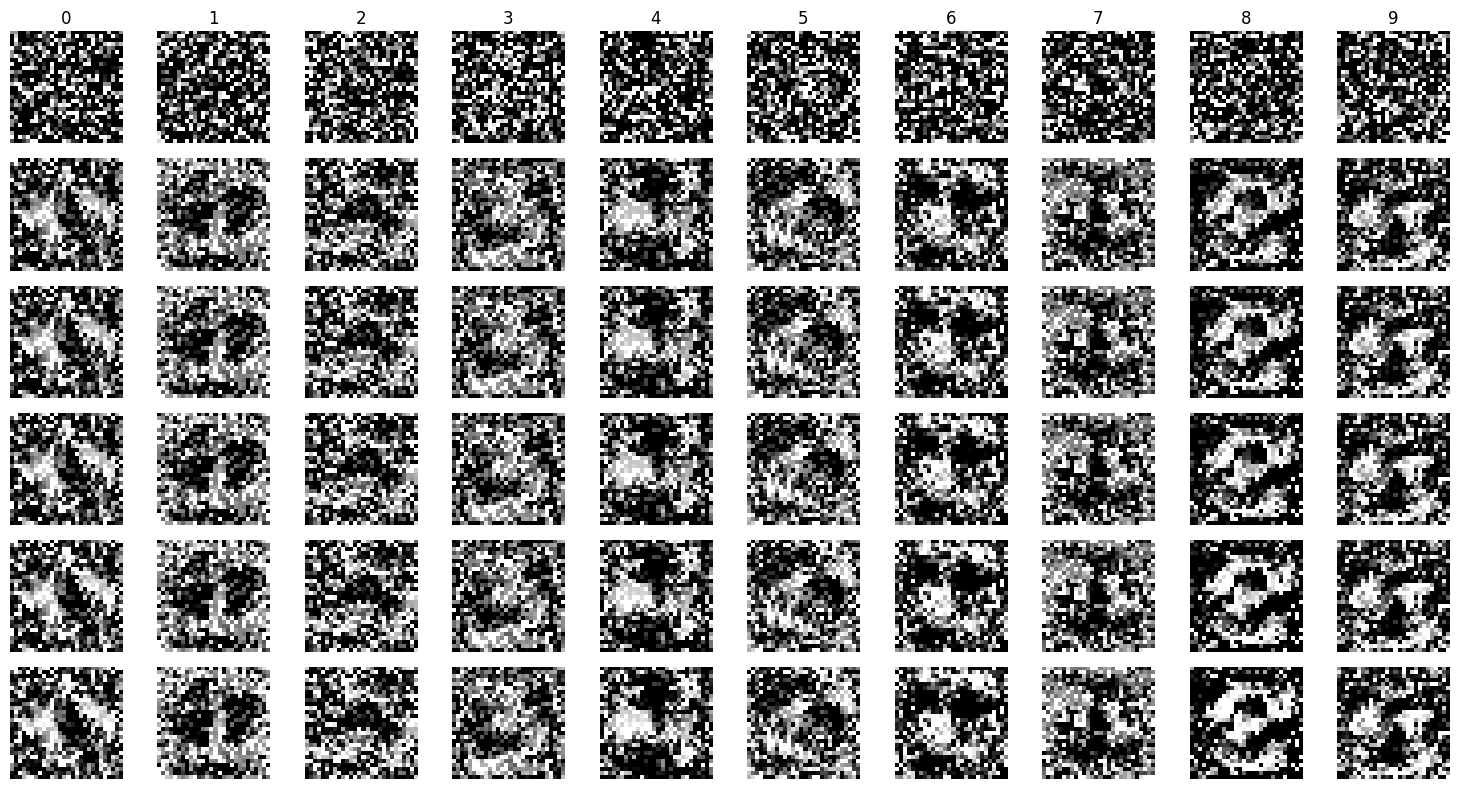

In [ ]:
fig, axes = plt.subplots(len(save_steps), 10, figsize=(15, 8))

for row, step in enumerate(save_steps):
    imgs = images_over_time[step]

    for i in range(10):
        axes[row, i].imshow(imgs[i][0], cmap='gray')
        axes[row, i].axis('off')

        if row == 0:
            axes[row, i].set_title(str(i))

    axes[row, 0].set_ylabel(f"step {step}")

plt.tight_layout()
plt.show()

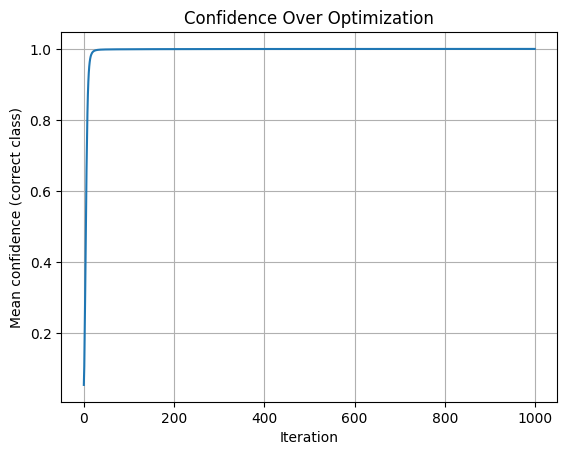

In [ ]:
plt.plot(conf_history)
plt.title("Confidence Over Optimization")
plt.xlabel("Iteration")
plt.ylabel("Mean confidence (correct class)")
plt.grid()
plt.show()

## Loss 0.01




In [ ]:
net.eval()
for p in net.parameters():
    p.requires_grad = False

# initialize trainable images
dreamed = torch.randn(10, 1, 28, 28, requires_grad=True)
targets = torch.arange(10)

optimizer = torch.optim.Adam([dreamed], lr=0.05)

# storage
save_steps = [0, 50, 100, 200, 500, 999]
images_over_time = {}
conf_history = []

for step in range(1000):
    optimizer.zero_grad()

    logits = net(dreamed)
    probs = F.softmax(logits, dim=1)

    loss = F.cross_entropy(logits, targets)

    lambda_l2 = 0.01   #loss
    loss += lambda_l2 * dreamed.pow(2).mean()

    loss.backward()
    optimizer.step()

    dreamed.data.clamp_(0, 1)

    # save images
    if step in save_steps:
        images_over_time[step] = dreamed.detach().cpu().clone()

    # track confidence (correct class)
    conf = probs[torch.arange(10), targets].mean().item()
    conf_history.append(conf)

    if step % 100 == 0:
        print(f"step {step}, loss {loss.item():.4f}, conf {conf:.4f}")

step 0, loss 4.0218, conf 0.1637
step 100, loss 0.0038, conf 0.9991
step 200, loss 0.0034, conf 0.9994
step 300, loss 0.0031, conf 0.9996
step 400, loss 0.0029, conf 0.9997
step 500, loss 0.0028, conf 0.9997
step 600, loss 0.0026, conf 0.9997
step 700, loss 0.0024, conf 0.9998
step 800, loss 0.0023, conf 0.9998
step 900, loss 0.0022, conf 0.9998


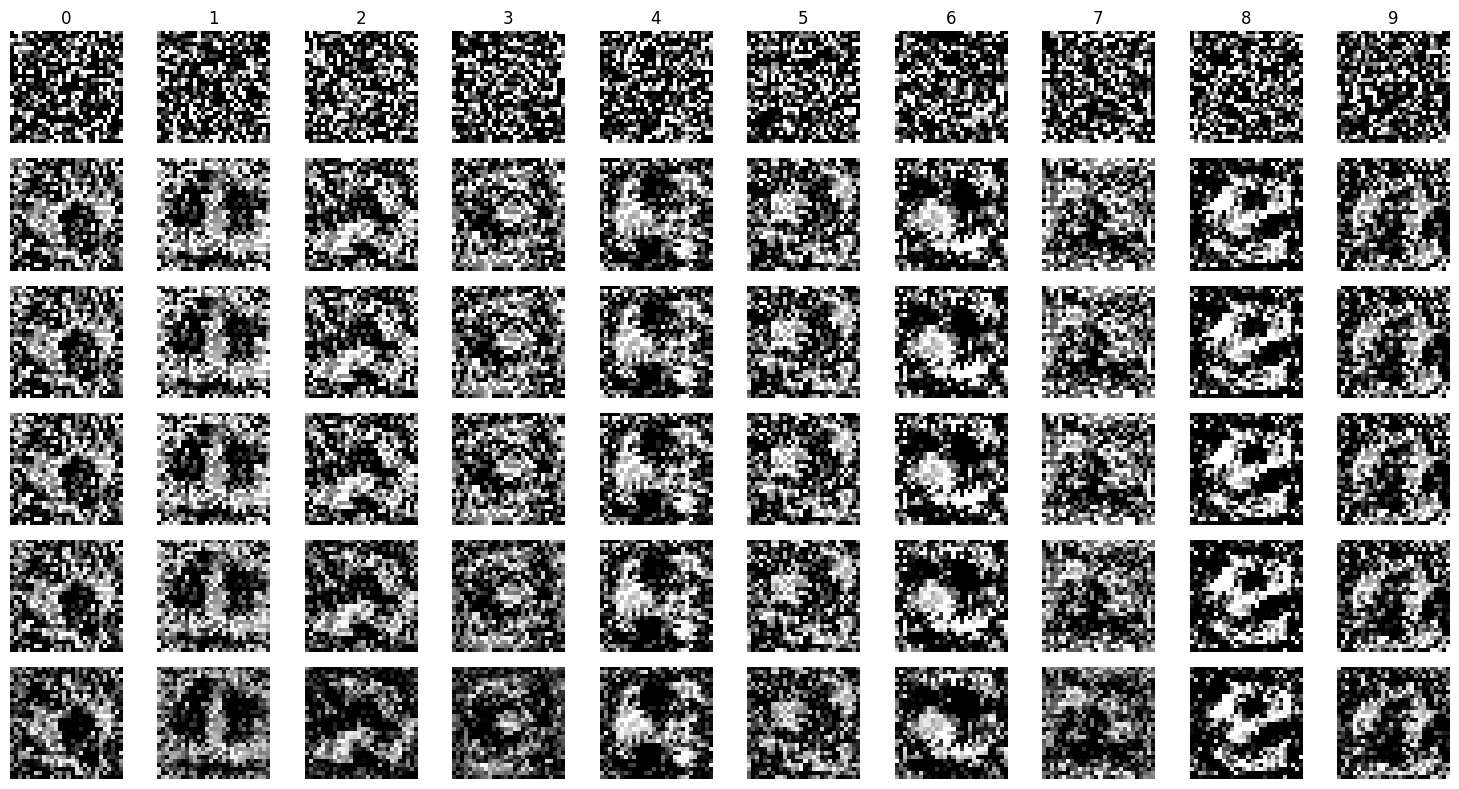

In [ ]:
fig, axes = plt.subplots(len(save_steps), 10, figsize=(15, 8))

for row, step in enumerate(save_steps):
    imgs = images_over_time[step]

    for i in range(10):
        axes[row, i].imshow(imgs[i][0], cmap='gray')
        axes[row, i].axis('off')

        if row == 0:
            axes[row, i].set_title(str(i))

    axes[row, 0].set_ylabel(f"step {step}")

plt.tight_layout()
plt.show()

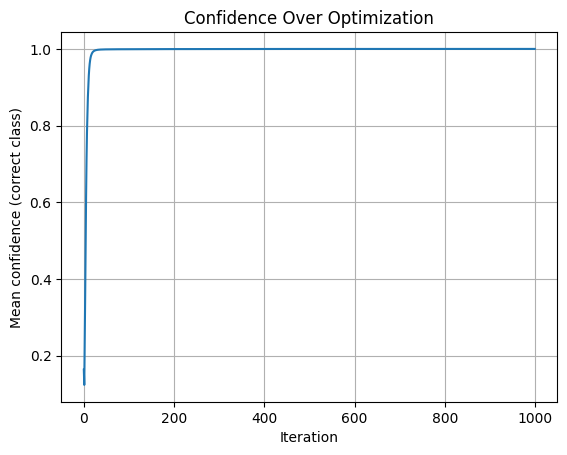

In [ ]:
plt.plot(conf_history)
plt.title("Confidence Over Optimization")
plt.xlabel("Iteration")
plt.ylabel("Mean confidence (correct class)")
plt.grid()
plt.show()

## Loss 0.1


In [66]:
net.eval()
for p in net.parameters():
    p.requires_grad = False

# initialize trainable images
dreamed = torch.randn(10, 1, 28, 28, requires_grad=True)
targets = torch.arange(10)

optimizer = torch.optim.Adam([dreamed], lr=0.05)

# storage
save_steps = [0, 50, 100, 200, 500, 999]
images_over_time = {}
conf_history = []

for step in range(1000):
    optimizer.zero_grad()

    logits = net(dreamed)
    probs = F.softmax(logits, dim=1)

    loss = F.cross_entropy(logits, targets)

    lambda_l2 = 0.1   #loss
    loss += lambda_l2 * dreamed.pow(2).mean()

    loss.backward()
    optimizer.step()

    dreamed.data.clamp_(0, 1)

    # save images
    if step in save_steps:
        images_over_time[step] = dreamed.detach().cpu().clone()

    # track confidence (correct class)
    conf = probs[torch.arange(10), targets].mean().item()
    conf_history.append(conf)

    if step % 100 == 0:
        print(f"step {step}, loss {loss.item():.4f}, conf {conf:.4f}")

step 0, loss 5.4565, conf 0.0862
step 100, loss 0.0254, conf 0.9989
step 200, loss 0.0194, conf 0.9988
step 300, loss 0.0149, conf 0.9988
step 400, loss 0.0119, conf 0.9988
step 500, loss 0.0099, conf 0.9988
step 600, loss 0.0087, conf 0.9987
step 700, loss 0.0080, conf 0.9987
step 800, loss 0.0075, conf 0.9987
step 900, loss 0.0072, conf 0.9987


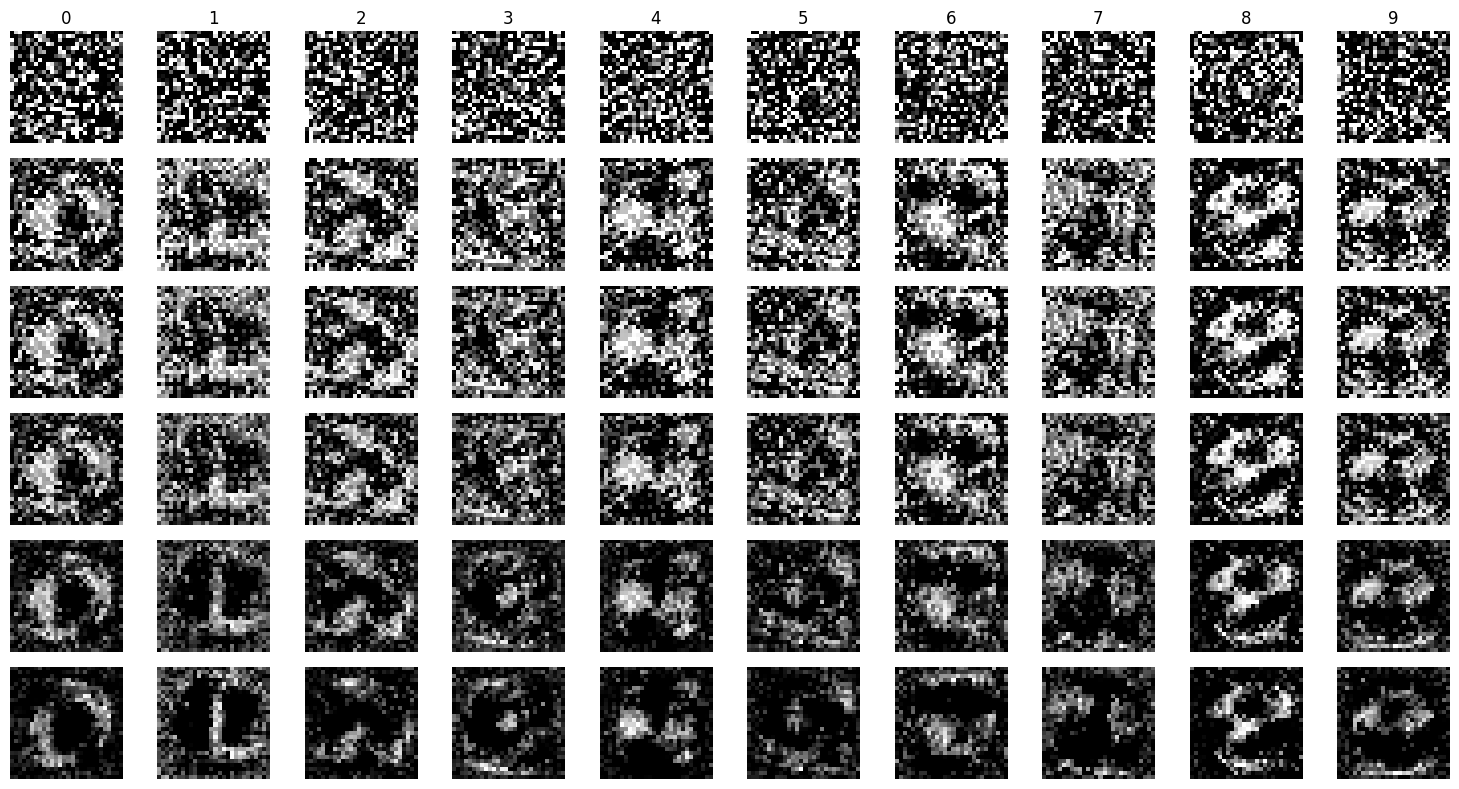

In [67]:
fig, axes = plt.subplots(len(save_steps), 10, figsize=(15, 8))

for row, step in enumerate(save_steps):
    imgs = images_over_time[step]

    for i in range(10):
        axes[row, i].imshow(imgs[i][0], cmap='gray')
        axes[row, i].axis('off')

        if row == 0:
            axes[row, i].set_title(str(i))

    axes[row, 0].set_ylabel(f"step {step}")

plt.tight_layout()
plt.show()

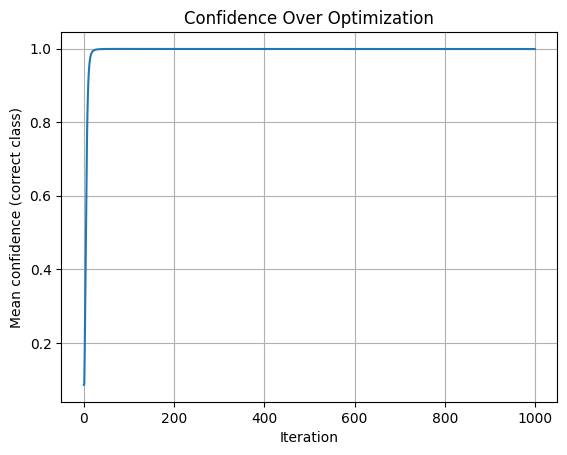

In [68]:
plt.plot(conf_history)
plt.title("Confidence Over Optimization")
plt.xlabel("Iteration")
plt.ylabel("Mean confidence (correct class)")
plt.grid()
plt.show()

## Loss 1

In [69]:
net.eval()
for p in net.parameters():
    p.requires_grad = False

# initialize trainable images
dreamed = torch.randn(10, 1, 28, 28, requires_grad=True)
targets = torch.arange(10)

optimizer = torch.optim.Adam([dreamed], lr=0.05)

# storage
save_steps = [0, 50, 100, 200, 500, 999]
images_over_time = {}
conf_history = []

for step in range(1000):
    optimizer.zero_grad()

    logits = net(dreamed)
    probs = F.softmax(logits, dim=1)

    loss = F.cross_entropy(logits, targets)

    lambda_l2 = 1   #loss
    loss += lambda_l2 * dreamed.pow(2).mean()

    loss.backward()
    optimizer.step()

    dreamed.data.clamp_(0, 1)

    # save images
    if step in save_steps:
        images_over_time[step] = dreamed.detach().cpu().clone()

    # track confidence (correct class)
    conf = probs[torch.arange(10), targets].mean().item()
    conf_history.append(conf)

    if step % 100 == 0:
        print(f"step {step}, loss {loss.item():.4f}, conf {conf:.4f}")

step 0, loss 5.9308, conf 0.0737
step 100, loss 0.0889, conf 0.9908
step 200, loss 0.0487, conf 0.9902
step 300, loss 0.0427, conf 0.9903
step 400, loss 0.0410, conf 0.9904
step 500, loss 0.0407, conf 0.9905
step 600, loss 0.0406, conf 0.9905
step 700, loss 0.0406, conf 0.9905
step 800, loss 0.0405, conf 0.9905
step 900, loss 0.0405, conf 0.9905


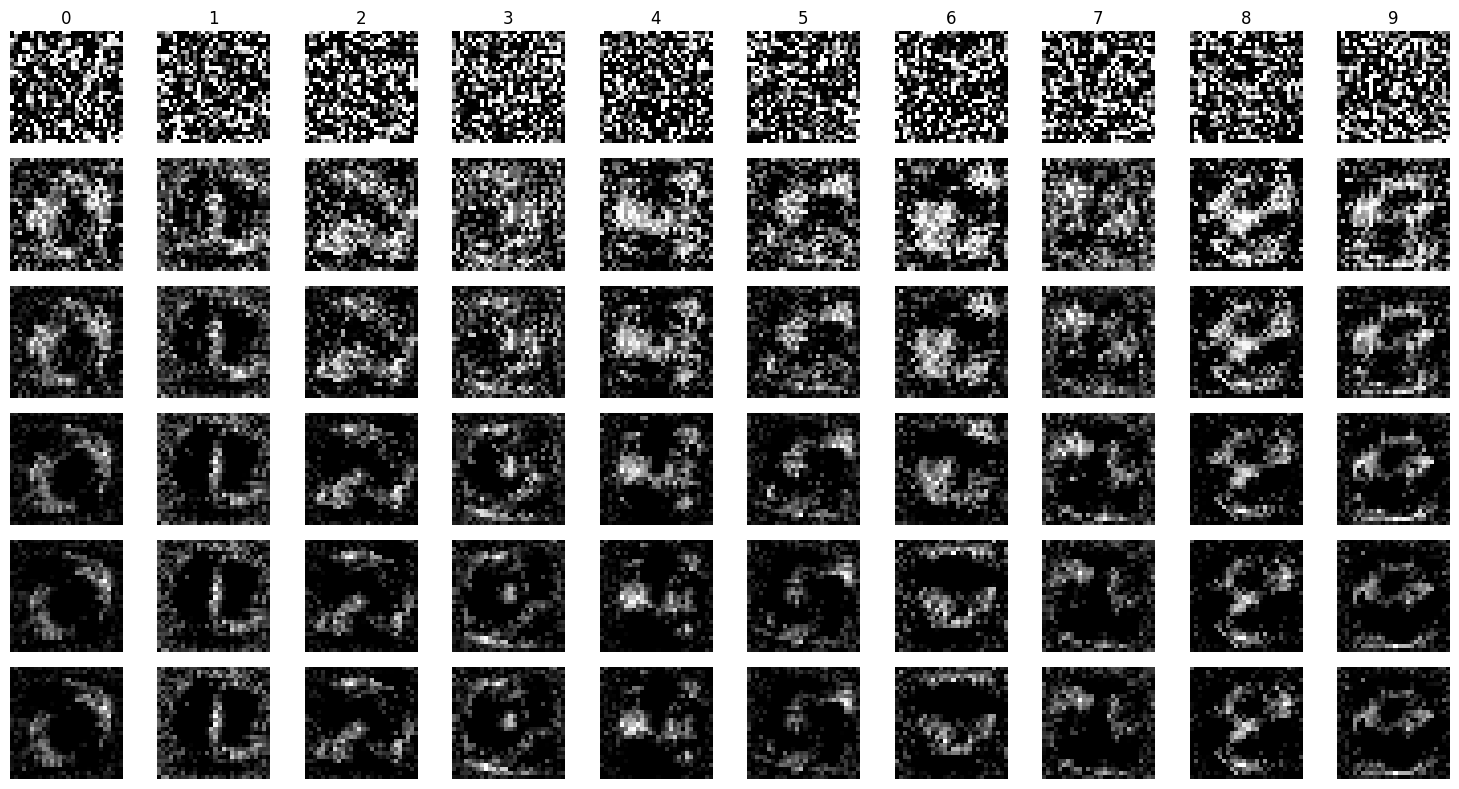

In [70]:
fig, axes = plt.subplots(len(save_steps), 10, figsize=(15, 8))

for row, step in enumerate(save_steps):
    imgs = images_over_time[step]

    for i in range(10):
        axes[row, i].imshow(imgs[i][0], cmap='gray')
        axes[row, i].axis('off')

        if row == 0:
            axes[row, i].set_title(str(i))

    axes[row, 0].set_ylabel(f"step {step}")

plt.tight_layout()
plt.show()

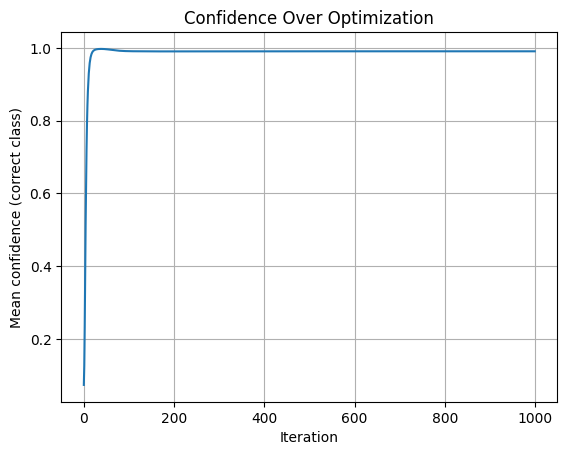

In [71]:
plt.plot(conf_history)
plt.title("Confidence Over Optimization")
plt.xlabel("Iteration")
plt.ylabel("Mean confidence (correct class)")
plt.grid()
plt.show()

## Loss 10

In [72]:
net.eval()
for p in net.parameters():
    p.requires_grad = False

# initialize trainable images
dreamed = torch.randn(10, 1, 28, 28, requires_grad=True)
targets = torch.arange(10)

optimizer = torch.optim.Adam([dreamed], lr=0.05)

# storage
save_steps = [0, 50, 100, 200, 500, 999]
images_over_time = {}
conf_history = []

for step in range(1000):
    optimizer.zero_grad()

    logits = net(dreamed)
    probs = F.softmax(logits, dim=1)

    loss = F.cross_entropy(logits, targets)

    lambda_l2 = 10   #loss
    loss += lambda_l2 * dreamed.pow(2).mean()

    loss.backward()
    optimizer.step()

    dreamed.data.clamp_(0, 1)

    # save images
    if step in save_steps:
        images_over_time[step] = dreamed.detach().cpu().clone()

    # track confidence (correct class)
    conf = probs[torch.arange(10), targets].mean().item()
    conf_history.append(conf)

    if step % 100 == 0:
        print(f"step {step}, loss {loss.item():.4f}, conf {conf:.4f}")

step 0, loss 14.2842, conf 0.0710
step 100, loss 0.2193, conf 0.9347
step 200, loss 0.2178, conf 0.9350
step 300, loss 0.2178, conf 0.9351
step 400, loss 0.2178, conf 0.9350
step 500, loss 0.2178, conf 0.9350
step 600, loss 0.2179, conf 0.9350
step 700, loss 0.2178, conf 0.9350
step 800, loss 0.2178, conf 0.9351
step 900, loss 0.2179, conf 0.9349


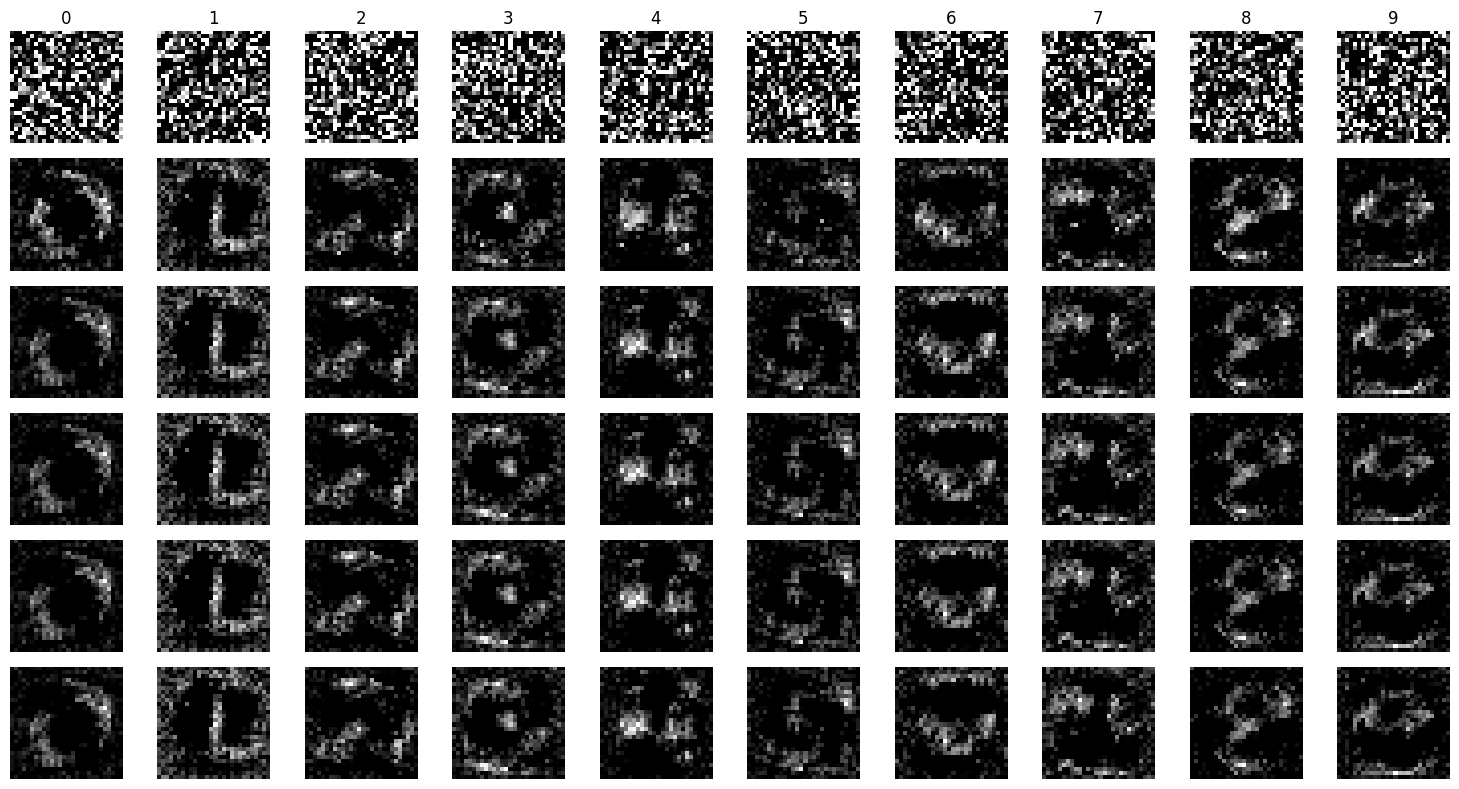

In [73]:
fig, axes = plt.subplots(len(save_steps), 10, figsize=(15, 8))

for row, step in enumerate(save_steps):
    imgs = images_over_time[step]

    for i in range(10):
        axes[row, i].imshow(imgs[i][0], cmap='gray')
        axes[row, i].axis('off')

        if row == 0:
            axes[row, i].set_title(str(i))

    axes[row, 0].set_ylabel(f"step {step}")

plt.tight_layout()
plt.show()

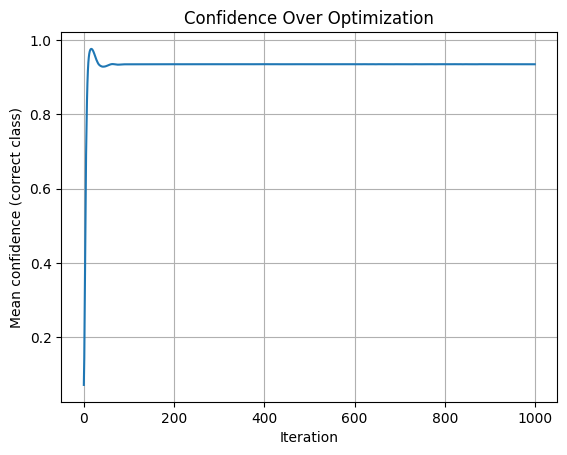

In [74]:
plt.plot(conf_history)
plt.title("Confidence Over Optimization")
plt.xlabel("Iteration")
plt.ylabel("Mean confidence (correct class)")
plt.grid()
plt.show()

## Loss 100

In [75]:
net.eval()
for p in net.parameters():
    p.requires_grad = False

# initialize trainable images
dreamed = torch.randn(10, 1, 28, 28, requires_grad=True)
targets = torch.arange(10)

optimizer = torch.optim.Adam([dreamed], lr=0.05)

# storage
save_steps = [0, 50, 100, 200, 500, 999]
images_over_time = {}
conf_history = []

for step in range(1000):
    optimizer.zero_grad()

    logits = net(dreamed)
    probs = F.softmax(logits, dim=1)

    loss = F.cross_entropy(logits, targets)

    lambda_l2 = 100   #loss
    loss += lambda_l2 * dreamed.pow(2).mean()

    loss.backward()
    optimizer.step()

    dreamed.data.clamp_(0, 1)

    # save images
    if step in save_steps:
        images_over_time[step] = dreamed.detach().cpu().clone()

    # track confidence (correct class)
    conf = probs[torch.arange(10), targets].mean().item()
    conf_history.append(conf)

    if step % 100 == 0:
        print(f"step {step}, loss {loss.item():.4f}, conf {conf:.4f}")

step 0, loss 104.9565, conf 0.1341
step 100, loss 0.9047, conf 0.6487
step 200, loss 0.9049, conf 0.6492
step 300, loss 0.9050, conf 0.6489
step 400, loss 0.9052, conf 0.6491
step 500, loss 0.9052, conf 0.6490
step 600, loss 0.9056, conf 0.6491
step 700, loss 0.9056, conf 0.6500
step 800, loss 0.9056, conf 0.6488
step 900, loss 0.9052, conf 0.6494


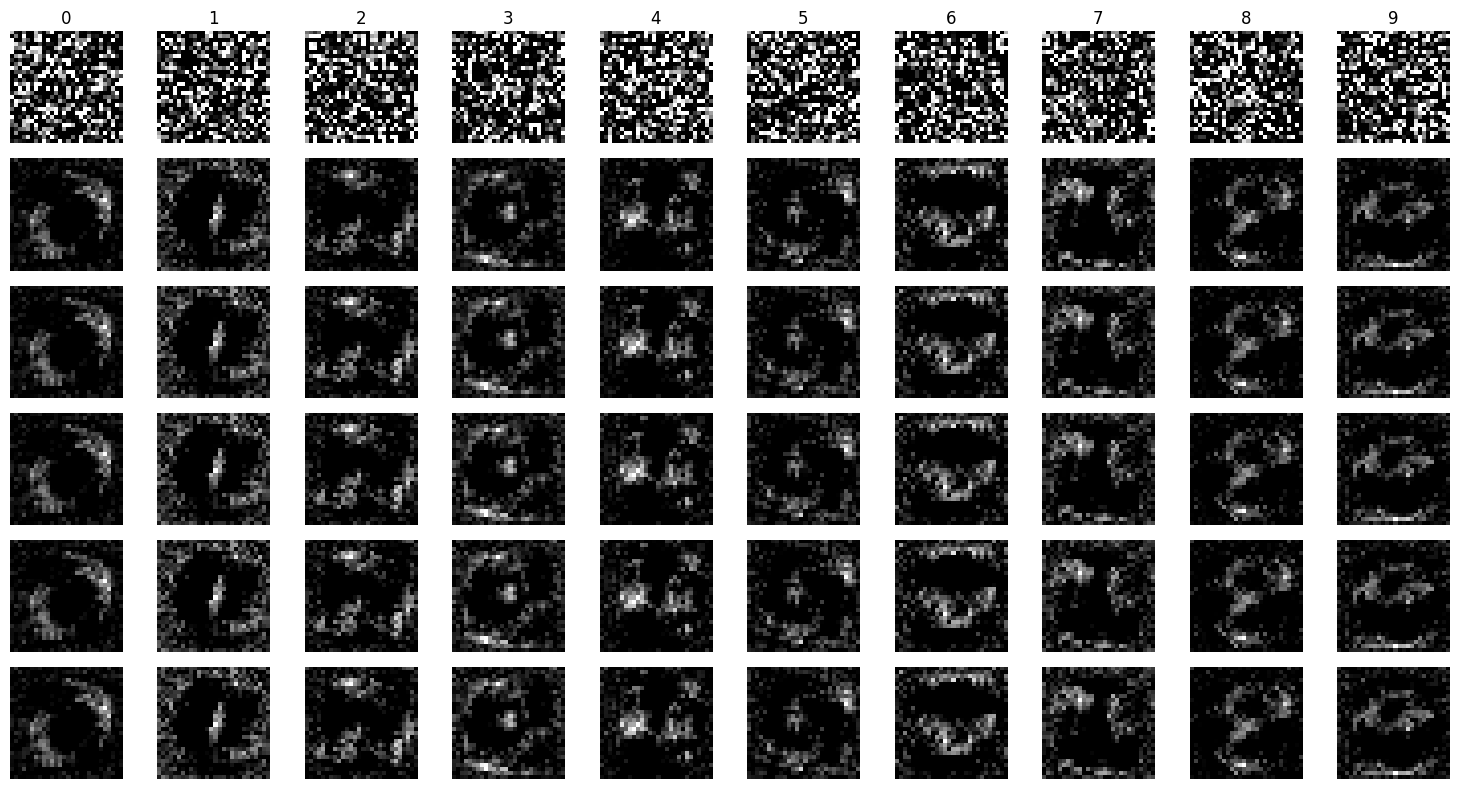

In [76]:
fig, axes = plt.subplots(len(save_steps), 10, figsize=(15, 8))

for row, step in enumerate(save_steps):
    imgs = images_over_time[step]

    for i in range(10):
        axes[row, i].imshow(imgs[i][0], cmap='gray')
        axes[row, i].axis('off')

        if row == 0:
            axes[row, i].set_title(str(i))

    axes[row, 0].set_ylabel(f"step {step}")

plt.tight_layout()
plt.show()

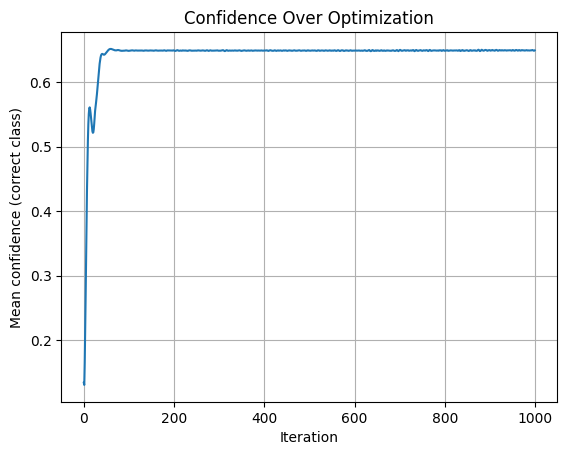

In [77]:
plt.plot(conf_history)
plt.title("Confidence Over Optimization")
plt.xlabel("Iteration")
plt.ylabel("Mean confidence (correct class)")
plt.grid()
plt.show()

- The generated images don’t look like real MNIST digits because nothing in the optimization forces them to stay similar to real handwritten numbers.

- Instead, the process just changes the pixels to make the model very confident in its prediction. In doing that, it uses small patterns that the network has learned, but these patterns don’t really make sense to humans.

- Some numbers have visible details. For example, we can see a straight line in number "1" classificator

- The images end up looking like strange, noisy shapes. The model recognizes them, but to us they don’t look like real digits.

- Adding an L2 penalty changes the optimization by discouraging large pixel values, which reduces noise and forces the generated images to be simpler and more structured.

- However, when the penalty becomes too strong, it dominates the classification objective. It loses class-specific features and is less confidently recognized by the model. With lambda = 10, confidence dropped from nearly 100% to 98%.
Lambda 100 made it much worse with confidence averaging 65%

#Task 2

In [ ]:
net.eval()

for p in net.parameters():
    p.requires_grad = False

# single image
hybrid = torch.randn(1, 1, 28, 28, requires_grad=True)
optimizer = torch.optim.Adam([hybrid], lr=0.05)

digit_a = 8
digit_b = 9

# soft target distribution
target = torch.zeros(1, 10)
target[0, digit_a] = 0.5
target[0, digit_b] = 0.5
target = target.to(hybrid.device)

for step in range(1000):
    optimizer.zero_grad()

    logits = net(hybrid)
    log_probs = F.log_softmax(logits, dim=1)

    # cross entropy with soft targets
    loss = -(target * log_probs).sum()

    loss.backward()
    optimizer.step()

    hybrid.data.clamp_(0, 1)

    if step % 100 == 0:
        print(f"step {step}, loss {loss.item():.4f}")

step 0, loss 7.7149
step 100, loss 0.7035
step 200, loss 0.6985
step 300, loss 0.6967
step 400, loss 0.6957
step 500, loss 0.6952
step 600, loss 0.6949
step 700, loss 0.6947
step 800, loss 0.6945
step 900, loss 0.6944


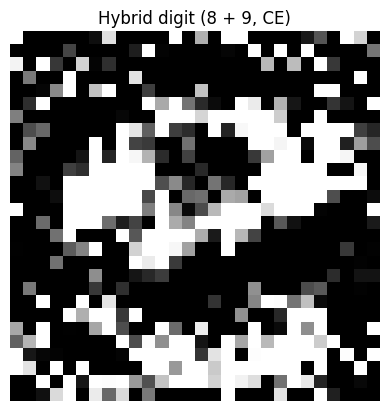

In [ ]:
img = hybrid.detach().cpu()[0][0]
img = (img - img.min()) / (img.max() - img.min())

plt.imshow(img, cmap='gray')
plt.title("Hybrid digit (8 + 9, CE)")
plt.axis('off')
plt.show()

In [ ]:
net.eval()

with torch.no_grad():
    logits = net(hybrid)
    probs = F.softmax(logits, dim=1)[0]

for i in range(10):
    print(f"Digit {i}: {probs[i].item():.4f}")

Digit 0: 0.0002
Digit 1: 0.0000
Digit 2: 0.0001
Digit 3: 0.0004
Digit 4: 0.0002
Digit 5: 0.0001
Digit 6: 0.0000
Digit 7: 0.0000
Digit 8: 0.4993
Digit 9: 0.4995


The generated image contains features of both digits. The optimization balances the evidence for each class, producing a hybrid representation.